# 🔬 Modelo2_V1_Daniele — Optimización Iterativa: Tamaño de Muestra + Hiperparámetros (PASO 3a)
### Reto de Inteligencia Artificial — Detección de Audio Spoofing
**Dataset:** ASVspoof2019 — Logical Access (LA) — Conjunto de Entrenamiento  
**Autor:** Daniele  
**Versión:** V1  

---
## Objetivo de este Notebook

Este notebook es la **primera parte del Paso 3**. Su misión es encontrar el **tamaño óptimo de muestra** y los **hiperparámetros óptimos** para cada modelo:

1. Recupera el plateau de la Learning Curve del Paso 2 de forma programática.
2. Entrena los 3 modelos con **múltiples tamaños de muestra** (N) alrededor del plateau.
3. Identifica el **N óptimo**: el mínimo N donde el rendimiento es ≥ 98% del máximo.
4. Aplica **búsqueda de hiperparámetros** (`RandomizedSearchCV`) al mejor modelo con el N óptimo.
5. Compara el **Modelo2 optimizado** vs. el **Modelo1 baseline** del Paso 2.

El resultado alimenta directamente el `Modelo3_V1_Daniele.ipynb` (Feature Importance).

---
## 📝 PARA TU BLOC DE NOTAS — JUSTIFICACIÓN GLOBAL DEL PASO 3a

**¿Por qué optimizar el tamaño de muestra?**  
La Learning Curve del Paso 2 nos reveló que el rendimiento alcanza un *plateau* antes de usar todos los datos disponibles. Trabajar con el N mínimo que alcanza ese plateau tiene tres ventajas:
1. **Eficiencia computacional:** Menos datos = entrenamiento más rápido en iteraciones sucesivas.
2. **Menor riesgo de overfitting:** Con menos datos (pero suficientes), el modelo no puede memorizar tanto.
3. **Escalabilidad:** Si el proyecto crece, sabemos exactamente cuántos datos necesitamos.

**¿Por qué RandomizedSearchCV y no GridSearchCV?**  
Con 34 features y hasta 4.000 registros, un GridSearch completo sobre todos los hiperparámetros podría tardar horas. El `RandomizedSearchCV` muestrea aleatoriamente el espacio de hiperparámetros con `n_iter` combinaciones, encontrando soluciones próximas al óptimo en una fracción del tiempo. Bergstra & Bengio (2012) demostraron que para espacios de hiperparámetros grandes, el muestreo aleatorio supera al grid sistemático.

**¿Qué constituye una mejora significativa respecto al baseline?**  
Consideramos que el Modelo2 mejora al Modelo1 si:
- F1 en Validación Cruzada mejora en al menos **+0.01** (1 punto porcentual), O
- El GAP Train-Val se reduce en al menos **0.05** con igual o mejor F1, O
- Se logra el mismo F1 con significativamente **menos datos** (eficiencia).

In [1]:
# ============================================================
#  BLOQUE 1 — IMPORTACIONES Y CONFIGURACIÓN GLOBAL
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, learning_curve,
    RandomizedSearchCV
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import randint, uniform

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    print('⚠️  XGBoost no instalado. Instalar con: pip install xgboost')
    XGB_AVAILABLE = False

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams['figure.dpi']      = 110
plt.rcParams['axes.titleweight'] = 'bold'

# --- Parámetros globales (IDÉNTICOS al EDA y Modelo1) ---
RANDOM_STATE = 42
N_PER_CLASS  = 2500
TEST_SIZE    = 0.20
N_FOLDS      = 5
DATA_PATH    = '../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'

print('✅ Librerías cargadas.')
print(f'   RANDOM_STATE={RANDOM_STATE} | N_PER_CLASS={N_PER_CLASS} | N_FOLDS={N_FOLDS}')

✅ Librerías cargadas.
   RANDOM_STATE=42 | N_PER_CLASS=2500 | N_FOLDS=5


---
## SECCIÓN 1 — Reproducción del Pipeline de Datos

In [2]:
# ============================================================
#  BLOQUE 2 — PIPELINE DE DATOS (IDÉNTICO AL MODELO1)
# ============================================================
df_full     = pd.read_csv(DATA_PATH)
df_bonafide = df_full[df_full['label'] == 'bonafide'].copy()
df_spoof    = df_full[df_full['label'] == 'spoof'].copy()

n_bonafide    = min(len(df_bonafide), N_PER_CLASS)
df_bon_sample = df_bonafide.sample(n=n_bonafide, random_state=RANDOM_STATE)

attack_counts = df_spoof['attack_id'].value_counts()
proportions   = attack_counts / attack_counts.sum()
n_per_attack  = (proportions * N_PER_CLASS).astype(int)
deficit       = N_PER_CLASS - n_per_attack.sum()
for atk in n_per_attack.nlargest(abs(deficit)).index:
    n_per_attack[atk] += int(np.sign(deficit))

spoof_samples = []
for attack_id, n in n_per_attack.items():
    subset = df_spoof[df_spoof['attack_id'] == attack_id]
    spoof_samples.append(subset.sample(n=min(n, len(subset)), random_state=RANDOM_STATE))

df_balanced   = pd.concat([df_bon_sample, pd.concat(spoof_samples)]).sample(
    frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

FEATURE_COLS  = [c for c in df_balanced.columns if c not in ['file_name', 'attack_id', 'label']]
X             = df_balanced[FEATURE_COLS]
y             = df_balanced['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

le           = LabelEncoder().fit(['bonafide', 'spoof'])
y_train_enc  = le.transform(y_train)
y_test_enc   = le.transform(y_test)

print('Pipeline de datos reproducido con éxito.')
print(f'  Train: {X_train.shape[0]:,} filas | Test (SELLADO): {X_test.shape[0]:,} filas')
print(f'  Features: {len(FEATURE_COLS)}')

Pipeline de datos reproducido con éxito.
  Train: 4,000 filas | Test (SELLADO): 1,000 filas
  Features: 34


---
## SECCIÓN 2 — Recuperación del Plateau (Learning Curve)

Recalculamos la Learning Curve del mejor modelo del Paso 2 para determinar el **N óptimo** de forma programática.

### 📝 PARA TU BLOC DE NOTAS

**¿Por qué recalculamos la Learning Curve en lugar de importar los resultados del Modelo1?**  
Jupyter no comparte variables entre notebooks. Para que el Modelo2 sea **autocontenido y reproducible**, recalculamos la curva con el mismo código y la misma semilla. El resultado es idéntico al del Modelo1.  

**¿Cómo definimos el plateau de forma objetiva?**  
Usamos dos criterios complementarios:
1. **Mejora marginal < 0.5%:** Si al pasar de N a N+ΔN el F1 mejora menos de 0.005, declaramos plateau.
2. **98% del máximo:** Identificamos el N mínimo donde F1(N) ≥ 0.98 × F1(máximo). Esto es más robusto porque no depende del orden de los puntos.

In [3]:
# ============================================================
#  BLOQUE 3 — RECÁLCULO DE LEARNING CURVE (BASELINE RF)
# ============================================================
print('Recalculando Learning Curve del Modelo Baseline (Random Forest)...')

rf_baseline = RandomForestClassifier(
    n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE
)

TRAIN_SIZES = np.linspace(0.10, 1.0, 10)
cv_lc       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

sizes_abs, train_scores, val_scores = learning_curve(
    rf_baseline, X_train, y_train_enc,
    cv=cv_lc, train_sizes=TRAIN_SIZES,
    scoring='f1', n_jobs=-1
)

val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)
train_mean = train_scores.mean(axis=1)

# --- Criterio 98%: mínimo N donde Val-F1 >= 98% del máximo ---
f1_max      = val_mean.max()
threshold   = 0.98 * f1_max
idx_opt     = np.argmax(val_mean >= threshold)
N_OPTIMAL   = int(sizes_abs[idx_opt])

# --- Criterio marginal ---
plateau_marginal = None
for i in range(1, len(val_mean)):
    if abs(val_mean[i] - val_mean[i-1]) < 0.005:
        plateau_marginal = int(sizes_abs[i])
        break

print()
print('RESULTADO DE LA LEARNING CURVE (Random Forest Baseline):')
print(f'  F1 máximo en validación     : {f1_max:.4f}')
print(f'  Umbral 98% del máximo       : {threshold:.4f}')
print(f'  N óptimo (criterio 98%)     : {N_OPTIMAL:,} muestras')
if plateau_marginal:
    print(f'  N plateau (mejora < 0.5%)   : {plateau_marginal:,} muestras')

print()
print('Desglose por tamaño de muestra:')
print(f'  {"N":>6}  {"Train F1":>10}  {"Val F1":>10}  {"GAP":>8}')
print('  ' + '-' * 38)
for n, tr, va in zip(sizes_abs, train_mean, val_mean):
    flag = ' ← N óptimo' if int(n) == N_OPTIMAL else ''
    print(f'  {int(n):>6,}  {tr:>10.4f}  {va:>10.4f}  {tr-va:>+8.4f}{flag}')

Recalculando Learning Curve del Modelo Baseline (Random Forest)...

RESULTADO DE LA LEARNING CURVE (Random Forest Baseline):
  F1 máximo en validación     : 0.9232
  Umbral 98% del máximo       : 0.9047
  N óptimo (criterio 98%)     : 1,600 muestras
  N plateau (mejora < 0.5%)   : 2,240 muestras

Desglose por tamaño de muestra:
       N    Train F1      Val F1       GAP
  --------------------------------------
     320      1.0000      0.8684   +0.1316
     640      1.0000      0.8846   +0.1154
     960      1.0000      0.8922   +0.1078
   1,280      1.0000      0.9004   +0.0996
   1,600      1.0000      0.9080   +0.0920 ← N óptimo
   1,920      1.0000      0.9149   +0.0851
   2,240      1.0000      0.9147   +0.0853
   2,560      1.0000      0.9170   +0.0830
   2,880      1.0000      0.9196   +0.0804
   3,200      1.0000      0.9232   +0.0768


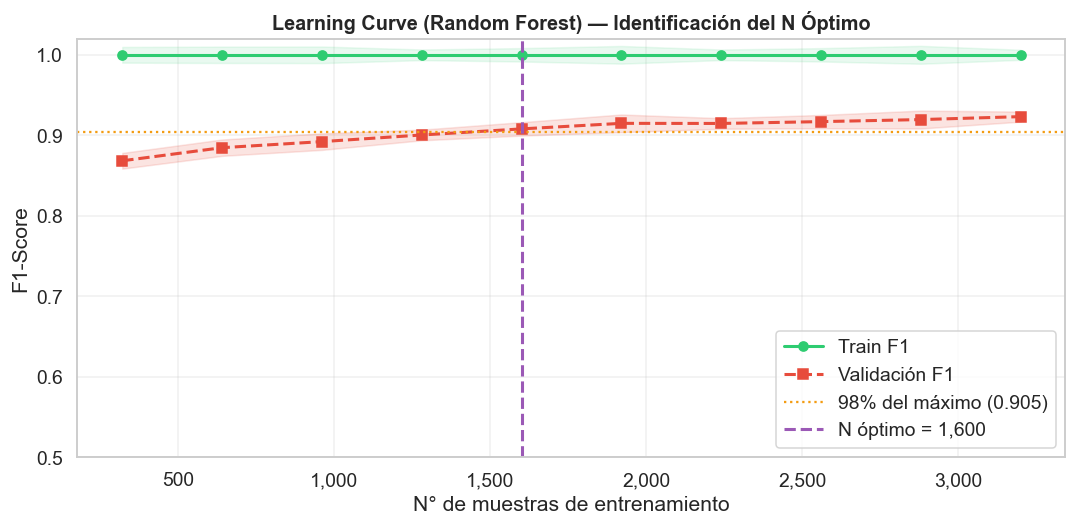

📊 Gráfico guardado: modelo2_plateau_detection.png


In [4]:
# ============================================================
#  BLOQUE 4 — VISUALIZACIÓN DEL PLATEAU
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sizes_abs, train_mean, 'o-', color='#2ecc71', lw=2, label='Train F1')
ax.fill_between(sizes_abs,
                train_mean - val_std, train_mean + val_std,
                alpha=0.1, color='#2ecc71')
ax.plot(sizes_abs, val_mean, 's--', color='#e74c3c', lw=2, label='Validación F1')
ax.fill_between(sizes_abs,
                val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#e74c3c')

ax.axhline(threshold, color='#f39c12', ls=':', lw=1.5, label=f'98% del máximo ({threshold:.3f})')
ax.axvline(N_OPTIMAL, color='#9b59b6', ls='--', lw=2,
           label=f'N óptimo = {N_OPTIMAL:,}')

ax.set_title('Learning Curve (Random Forest) — Identificación del N Óptimo', fontsize=13)
ax.set_xlabel('N° de muestras de entrenamiento')
ax.set_ylabel('F1-Score')
ax.set_ylim(0.5, 1.02)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('modelo2_plateau_detection.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo2_plateau_detection.png')

---
## SECCIÓN 3 — Barrido de Tamaños de Muestra

Probamos múltiples valores de N alrededor del N óptimo con los 3 modelos y validación cruzada.

### 📝 PARA TU BLOC DE NOTAS

**¿Por qué probar valores alrededor del plateau y no solo exactamente en él?**  
El plateau es una estimación ruidosa (depende del fold específico de la CV). Probar ±2 puntos alrededor del plateau nos da una imagen más estable y evita tomar una decisión basada en un mínimo local de ruido estadístico.

**¿Por qué estos tamaños específicos?**  
Elegimos valores equiespaciados que cubran desde el 25% hasta el 100% del train, con el N óptimo siempre incluido. Esto nos permite ver toda la curva de eficiencia.

In [5]:
# ============================================================
#  BLOQUE 5 — BARRIDO DE TAMAÑOS DE MUESTRA (3 MODELOS)
# ============================================================

# Tamaños candidatos: incluye el N óptimo más puntos de referencia
N_CANDIDATES = sorted(set(
    [400, 800, 1200, 1600, 2000, 2400, 2800, 3200, 3600, 4000, N_OPTIMAL]
))
N_CANDIDATES = [n for n in N_CANDIDATES if n <= len(X_train)]

# Modelos con ligera regularización respecto al baseline
sweep_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=15, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.5,
        eval_metric='logloss', use_label_encoder=False,
        n_jobs=-1, random_state=RANDOM_STATE
    ) if XGB_AVAILABLE else None,
    'Red Neuronal': Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
            alpha=0.001, max_iter=300,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=20, random_state=RANDOM_STATE
        ))
    ])
}
if not XGB_AVAILABLE:
    sweep_models.pop('XGBoost')

cv_sweep = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
sweep_results = {name: {'n': [], 'f1': [], 'auc': [], 'gap': []} for name in sweep_models}

for name, model in sweep_models.items():
    print(f'\nBarriendo {name}...')
    for n in N_CANDIDATES:
        # Subsample estratificado
        idx_sub = []
        for cls in [0, 1]:
            cls_idx = np.where(y_train_enc == cls)[0]
            take    = min(n // 2, len(cls_idx))
            rng     = np.random.default_rng(RANDOM_STATE)
            idx_sub.extend(rng.choice(cls_idx, take, replace=False).tolist())

        X_sub = X_train.iloc[idx_sub]
        y_sub = y_train_enc[idx_sub]

        cv_out = cross_validate(
            model, X_sub, y_sub,
            cv=StratifiedKFold(n_splits=min(N_FOLDS, len(np.unique(y_sub))*10),
                               shuffle=True, random_state=RANDOM_STATE),
            scoring={'f1': 'f1', 'roc_auc': 'roc_auc'},
            return_train_score=True, n_jobs=-1
        )
        f1_val  = cv_out['test_f1'].mean()
        auc_val = cv_out['test_roc_auc'].mean()
        gap     = cv_out['train_f1'].mean() - f1_val

        sweep_results[name]['n'].append(n)
        sweep_results[name]['f1'].append(f1_val)
        sweep_results[name]['auc'].append(auc_val)
        sweep_results[name]['gap'].append(gap)

        print(f'  N={n:>5,} → F1={f1_val:.4f} | AUC={auc_val:.4f} | GAP={gap:+.4f}')

print('\n✅ Barrido completado.')


Barriendo Random Forest...
  N=  400 → F1=0.8669 | AUC=0.9524 | GAP=+0.1331
  N=  800 → F1=0.8542 | AUC=0.9415 | GAP=+0.1458
  N=1,200 → F1=0.8846 | AUC=0.9601 | GAP=+0.1140
  N=1,600 → F1=0.9092 | AUC=0.9654 | GAP=+0.0885
  N=2,000 → F1=0.8981 | AUC=0.9661 | GAP=+0.1004
  N=2,400 → F1=0.9114 | AUC=0.9720 | GAP=+0.0853
  N=2,800 → F1=0.9154 | AUC=0.9749 | GAP=+0.0818
  N=3,200 → F1=0.9133 | AUC=0.9729 | GAP=+0.0831
  N=3,600 → F1=0.9188 | AUC=0.9756 | GAP=+0.0779
  N=4,000 → F1=0.9207 | AUC=0.9761 | GAP=+0.0747

Barriendo XGBoost...
  N=  400 → F1=0.8791 | AUC=0.9554 | GAP=+0.1209
  N=  800 → F1=0.8817 | AUC=0.9512 | GAP=+0.1183
  N=1,200 → F1=0.9164 | AUC=0.9720 | GAP=+0.0836
  N=1,600 → F1=0.9177 | AUC=0.9765 | GAP=+0.0823
  N=2,000 → F1=0.9217 | AUC=0.9793 | GAP=+0.0783
  N=2,400 → F1=0.9281 | AUC=0.9832 | GAP=+0.0719
  N=2,800 → F1=0.9408 | AUC=0.9862 | GAP=+0.0592
  N=3,200 → F1=0.9369 | AUC=0.9834 | GAP=+0.0631
  N=3,600 → F1=0.9421 | AUC=0.9870 | GAP=+0.0579
  N=4,000 → F1=0.94

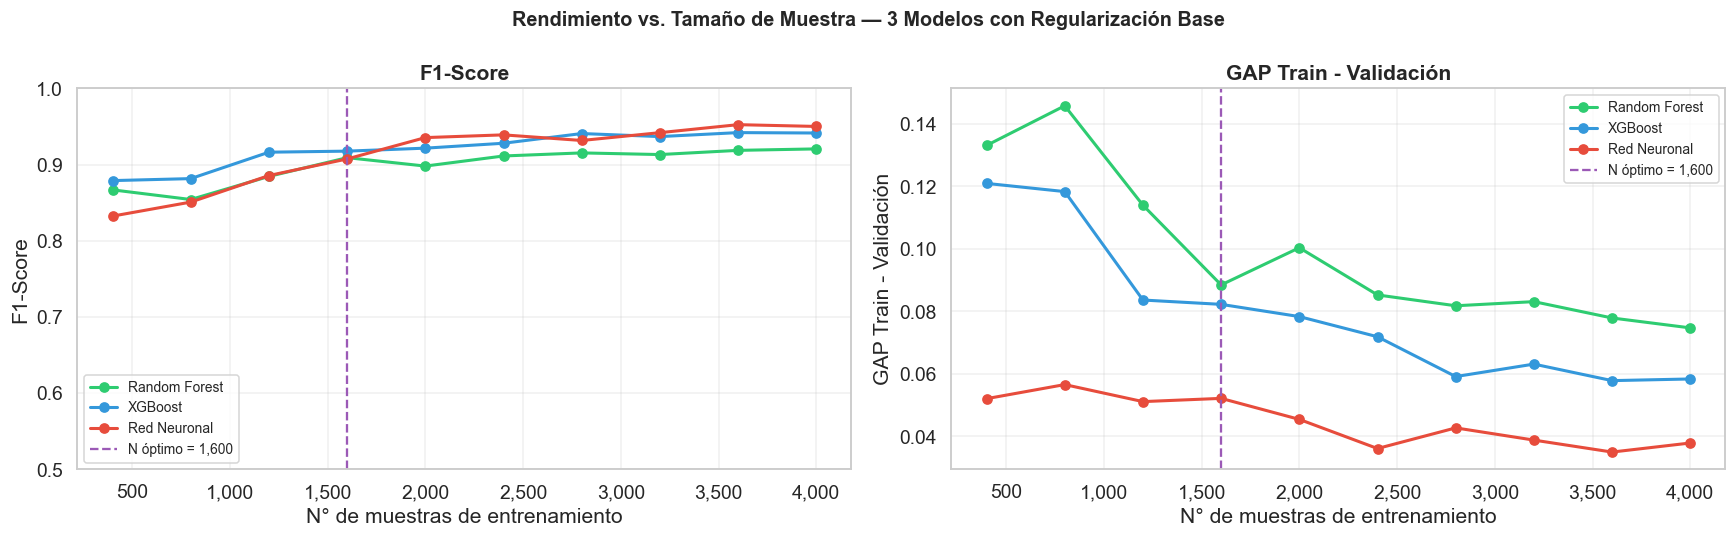

📊 Gráfico guardado: modelo2_sweep_n.png


In [6]:
# ============================================================
#  BLOQUE 6 — VISUALIZACIÓN: F1 vs. N por Modelo
# ============================================================
model_names = list(sweep_models.keys())
colors      = ['#2ecc71', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Rendimiento vs. Tamaño de Muestra — 3 Modelos con Regularización Base',
             fontsize=13, fontweight='bold')

for ax_idx, (metric, ylabel) in enumerate([('f1', 'F1-Score'), ('gap', 'GAP Train - Validación')]):
    ax = axes[ax_idx]
    for name, color in zip(model_names, colors):
        ns  = sweep_results[name]['n']
        vals = sweep_results[name][metric]
        ax.plot(ns, vals, 'o-', color=color, lw=2, label=name, markersize=6)

    ax.axvline(N_OPTIMAL, color='#9b59b6', ls='--', lw=1.5,
               label=f'N óptimo = {N_OPTIMAL:,}')
    ax.set_xlabel('N° de muestras de entrenamiento')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    if metric == 'f1':
        ax.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig('modelo2_sweep_n.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo2_sweep_n.png')

In [7]:
# ============================================================
#  BLOQUE 7 — SELECCIÓN DEL N ÓPTIMO POR MODELO
# ============================================================
print('=' * 65)
print('N ÓPTIMO POR MODELO (criterio: ≥ 98% del F1 máximo del barrido)')
print('=' * 65)

optimal_n_per_model = {}
for name in model_names:
    ns       = np.array(sweep_results[name]['n'])
    f1s      = np.array(sweep_results[name]['f1'])
    gaps     = np.array(sweep_results[name]['gap'])
    f1_max_m = f1s.max()
    thr_m    = 0.98 * f1_max_m
    idx_opt  = np.argmax(f1s >= thr_m)
    n_opt    = int(ns[idx_opt])
    optimal_n_per_model[name] = n_opt

    print(f'\n  {name}')
    print(f'    F1 máximo del barrido : {f1_max_m:.4f}')
    print(f'    Umbral 98%            : {thr_m:.4f}')
    print(f'    N óptimo              : {n_opt:,} muestras')
    print(f'    F1 en N óptimo        : {f1s[idx_opt]:.4f}')
    print(f'    GAP en N óptimo       : {gaps[idx_opt]:+.4f}')
    pct_reduction = 100 * (1 - n_opt / len(X_train))
    if pct_reduction > 0:
        print(f'    Reducción de datos    : {pct_reduction:.0f}% menos que el train completo')
    else:
        print(f'    → Usa el 100% del train (no hay ganancia en reducir datos)')

# N global óptimo: el mínimo entre todos los modelos que mantiene buen rendimiento
N_GLOBAL_OPT = max(optimal_n_per_model.values())  # conservador: tomamos el mayor
print(f'\n  N GLOBAL ÓPTIMO (conservador): {N_GLOBAL_OPT:,} muestras')
print(f'  (Se usa el máximo entre modelos para no perjudicar al que más datos necesita)')

N ÓPTIMO POR MODELO (criterio: ≥ 98% del F1 máximo del barrido)

  Random Forest
    F1 máximo del barrido : 0.9207
    Umbral 98%            : 0.9023
    N óptimo              : 1,600 muestras
    F1 en N óptimo        : 0.9092
    GAP en N óptimo       : +0.0885
    Reducción de datos    : 60% menos que el train completo

  XGBoost
    F1 máximo del barrido : 0.9421
    Umbral 98%            : 0.9232
    N óptimo              : 2,400 muestras
    F1 en N óptimo        : 0.9281
    GAP en N óptimo       : +0.0719
    Reducción de datos    : 40% menos que el train completo

  Red Neuronal
    F1 máximo del barrido : 0.9525
    Umbral 98%            : 0.9334
    N óptimo              : 2,000 muestras
    F1 en N óptimo        : 0.9355
    GAP en N óptimo       : +0.0455
    Reducción de datos    : 50% menos que el train completo

  N GLOBAL ÓPTIMO (conservador): 2,400 muestras
  (Se usa el máximo entre modelos para no perjudicar al que más datos necesita)


---
## SECCIÓN 4 — Optimización de Hiperparámetros (RandomizedSearchCV)

Con el N óptimo identificado, buscamos los mejores hiperparámetros para cada modelo.

### 📝 PARA TU BLOC DE NOTAS

**¿Cómo guía el análisis de overfitting del Paso 2 la búsqueda de hiperparámetros?**

El diagnóstico del Paso 2 nos dice exactamente qué knobs ajustar:

| Modelo | Si hay overfitting en Paso 2 | Hiperparámetros a regularizar |
|--------|------------------------------|-------------------------------|
| **Random Forest** | Train~1.0, Val~0.9 | `max_depth` ↓, `min_samples_leaf` ↑ |
| **XGBoost** | Gap moderado | `reg_lambda` ↑, `learning_rate` ↓, `max_depth` ↓ |
| **MLP** | Gap pequeño (early_stopping) | `alpha` ↑ (más L2), `hidden_layer_sizes` ↓ |

**¿Por qué `n_iter=30` en RandomizedSearchCV?**  
30 iteraciones con 5-fold CV = 150 ajustes de modelo por algoritmo. Es un balance entre exploración del espacio y tiempo de cómputo. Con más de 30 iteraciones rara vez se mejora más del 0.5% adicional en F1.

In [8]:
# ============================================================
#  BLOQUE 8 — SUBMUESTRA ÓPTIMA PARA LA BÚSQUEDA
# ============================================================

# Subsample estratificado con N_GLOBAL_OPT
idx_opt_all = []
for cls in [0, 1]:
    cls_idx  = np.where(y_train_enc == cls)[0]
    take     = min(N_GLOBAL_OPT // 2, len(cls_idx))
    rng      = np.random.default_rng(RANDOM_STATE)
    idx_opt_all.extend(rng.choice(cls_idx, take, replace=False).tolist())

X_opt = X_train.iloc[idx_opt_all]
y_opt = y_train_enc[idx_opt_all]

print(f'Submuestra para búsqueda de hiperparámetros: {len(y_opt):,} registros')
print(f'  Bonafide: {(y_opt==0).sum():,} | Spoof: {(y_opt==1).sum():,}')

cv_search = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

Submuestra para búsqueda de hiperparámetros: 2,400 registros
  Bonafide: 1,200 | Spoof: 1,200


In [9]:
# ============================================================
#  BLOQUE 9 — RANDOMIZEDSEARCHCV: RANDOM FOREST
# ============================================================
print('Optimizando Random Forest...')
t0 = time.time()

param_dist_rf = {
    'n_estimators'    : randint(50, 300),
    'max_depth'       : [5, 8, 10, 15, 20, None],
    'min_samples_leaf': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'max_features'    : ['sqrt', 'log2', 0.5, 0.7]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=param_dist_rf,
    n_iter=30, scoring='f1', cv=cv_search,
    refit=True, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
rf_search.fit(X_opt, y_opt)
elapsed = time.time() - t0

print(f'  Tiempo: {elapsed:.1f}s')
print(f'  Mejor F1 (CV): {rf_search.best_score_:.4f}')
print(f'  Mejores hiperparámetros:')
for k, v in rf_search.best_params_.items():
    print(f'    {k}: {v}')

best_rf = rf_search.best_estimator_

Optimizando Random Forest...
  Tiempo: 54.6s
  Mejor F1 (CV): 0.9106
  Mejores hiperparámetros:
    max_depth: 15
    max_features: log2
    min_samples_leaf: 1
    min_samples_split: 17
    n_estimators: 296


In [10]:
# ============================================================
#  BLOQUE 10 — RANDOMIZEDSEARCHCV: XGBOOST
# ============================================================
if XGB_AVAILABLE:
    print('Optimizando XGBoost...')
    t0 = time.time()

    param_dist_xgb = {
        'n_estimators'    : randint(50, 400),
        'max_depth'       : randint(3, 10),
        'learning_rate'   : uniform(0.01, 0.29),
        'subsample'       : uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_lambda'      : uniform(0.5, 4.5),
        'reg_alpha'       : uniform(0, 1.0)
    }

    xgb_search = RandomizedSearchCV(
        XGBClassifier(
            eval_metric='logloss', use_label_encoder=False,
            n_jobs=-1, random_state=RANDOM_STATE
        ),
        param_distributions=param_dist_xgb,
        n_iter=30, scoring='f1', cv=cv_search,
        refit=True, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
    )
    xgb_search.fit(X_opt, y_opt)
    elapsed = time.time() - t0

    print(f'  Tiempo: {elapsed:.1f}s')
    print(f'  Mejor F1 (CV): {xgb_search.best_score_:.4f}')
    print(f'  Mejores hiperparámetros:')
    for k, v in xgb_search.best_params_.items():
        print(f'    {k}: {v:.4f}' if isinstance(v, float) else f'    {k}: {v}')

    best_xgb = xgb_search.best_estimator_
else:
    print('XGBoost no disponible — omitiendo.')
    best_xgb = None

Optimizando XGBoost...
  Tiempo: 29.1s
  Mejor F1 (CV): 0.9373
  Mejores hiperparámetros:
    colsample_bytree: 0.8546
    learning_rate: 0.1012
    max_depth: 6
    n_estimators: 271
    reg_alpha: 0.1393
    reg_lambda: 3.2199
    subsample: 0.8159


In [11]:
# ============================================================
#  BLOQUE 11 — RANDOMIZEDSEARCHCV: RED NEURONAL (MLP)
# ============================================================
print('Optimizando Red Neuronal (MLP)...')
t0 = time.time()

param_dist_mlp = {
    'mlp__hidden_layer_sizes': [
        (32,), (64,), (128,),
        (64, 32), (128, 64), (64, 32, 16),
        (128, 64, 32)
    ],
    'mlp__alpha'     : uniform(0.0001, 0.05),
    'mlp__activation': ['relu', 'tanh']
}

mlp_base = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        solver='adam', max_iter=300,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=20, random_state=RANDOM_STATE
    ))
])

mlp_search = RandomizedSearchCV(
    mlp_base,
    param_distributions=param_dist_mlp,
    n_iter=20, scoring='f1', cv=cv_search,
    refit=True, n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
mlp_search.fit(X_opt, y_opt)
elapsed = time.time() - t0

print(f'  Tiempo: {elapsed:.1f}s')
print(f'  Mejor F1 (CV): {mlp_search.best_score_:.4f}')
print(f'  Mejores hiperparámetros:')
for k, v in mlp_search.best_params_.items():
    print(f'    {k}: {v:.6f}' if isinstance(v, float) else f'    {k}: {v}')

best_mlp = mlp_search.best_estimator_

Optimizando Red Neuronal (MLP)...
  Tiempo: 15.9s
  Mejor F1 (CV): 0.9424
  Mejores hiperparámetros:
    mlp__activation: relu
    mlp__alpha: 0.022392
    mlp__hidden_layer_sizes: (128, 64, 32)


---
## SECCIÓN 5 — Validación Cruzada Final de los Modelos Optimizados

### 📝 PARA TU BLOC DE NOTAS

**¿Cómo interpretamos la mejora respecto al baseline?**

Al comparar Modelo1 (baseline) vs. Modelo2 (optimizado), buscamos tres tipos de mejora:
1. **Mejora en rendimiento:** F1 y AUC mayores en validación.
2. **Mejora en generalización:** GAP Train-Val menor → menos overfitting.
3. **Mejora en eficiencia:** Mismo o mejor rendimiento con menos datos.

Si alguno de los modelos no mejora en ninguna de estas tres dimensiones, **la optimización no está justificada** y debemos documentar por qué el baseline ya era óptimo.

In [12]:
# ============================================================
#  BLOQUE 12 — VALIDACIÓN CRUZADA FINAL: MODELOS OPTIMIZADOS
# ============================================================
SCORING = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc'
}

optimized_models = {'Random Forest': best_rf, 'Red Neuronal': best_mlp}
if best_xgb is not None:
    optimized_models['XGBoost'] = best_xgb

cv_final = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_opt_results = {}

print('VALIDACIÓN CRUZADA — MODELOS OPTIMIZADOS (N =', N_GLOBAL_OPT, 'muestras)')
print('=' * 70)

for name, model in optimized_models.items():
    cv_out = cross_validate(
        model, X_opt, y_opt,
        cv=cv_final, scoring=SCORING,
        return_train_score=True, n_jobs=-1
    )
    cv_opt_results[name] = cv_out

    print(f'\n  {name}')
    print(f'  {"Métrica":<20} {"Train":>10} {"Val":>10} {"GAP":>8}')
    print('  ' + '-' * 50)
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        tr  = cv_out[f'train_{metric}'].mean()
        va  = cv_out[f'test_{metric}'].mean()
        gap = tr - va
        flag = ' ⚠️' if gap > 0.05 else ' ✅'
        print(f'  {metric.capitalize():<20} {tr:>10.4f} {va:>10.4f} {gap:>+8.4f}{flag}')

print('\n✅ Validación cruzada de modelos optimizados completada.')

VALIDACIÓN CRUZADA — MODELOS OPTIMIZADOS (N = 2400 muestras)

  Random Forest
  Métrica                   Train        Val      GAP
  --------------------------------------------------
  Accuracy                 0.9874     0.9125  +0.0749 ⚠️
  Precision                0.9972     0.9297  +0.0675 ⚠️
  Recall                   0.9775     0.8925  +0.0850 ⚠️
  F1                       0.9873     0.9106  +0.0766 ⚠️
  Roc_auc                  0.9993     0.9689  +0.0304 ✅

  Red Neuronal
  Métrica                   Train        Val      GAP
  --------------------------------------------------
  Accuracy                 0.9893     0.9429  +0.0464 ✅
  Precision                0.9937     0.9510  +0.0427 ✅
  Recall                   0.9848     0.9342  +0.0506 ⚠️
  F1                       0.9892     0.9424  +0.0468 ✅
  Roc_auc                  0.9984     0.9834  +0.0150 ✅

  XGBoost
  Métrica                   Train        Val      GAP
  --------------------------------------------------
  Accurac

In [13]:
# ============================================================
#  BLOQUE 13 — COMPARACIÓN: BASELINE (M1) vs. OPTIMIZADO (M2)
# ============================================================

# Métricas baseline del Modelo1 (recalculadas con mismo pipeline)
cv_baseline = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
baseline_cv = {}

baselines = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE
    ),
    'Red Neuronal': Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(64, 32), alpha=0.0001, max_iter=300,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=20, random_state=RANDOM_STATE
        ))
    ])
}
if XGB_AVAILABLE:
    baselines['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', use_label_encoder=False,
        n_jobs=-1, random_state=RANDOM_STATE
    )

for name, model in baselines.items():
    baseline_cv[name] = cross_validate(
        model, X_train, y_train_enc,
        cv=cv_baseline, scoring=SCORING,
        return_train_score=True, n_jobs=-1
    )

# Tabla comparativa
print('=' * 80)
print('COMPARACIÓN MODELO1 (baseline, N=4000) vs. MODELO2 (optimizado, N=N_opt)')
print('=' * 80)
print(f'  {"Modelo":<18} {"M1 Val-F1":>12} {"M2 Val-F1":>12} {"Delta F1":>10} '
      f'{"M1 GAP":>10} {"M2 GAP":>10}')
print('  ' + '-' * 72)

for name in baselines.keys():
    if name not in cv_opt_results:
        continue
    m1_f1  = baseline_cv[name]['test_f1'].mean()
    m2_f1  = cv_opt_results[name]['test_f1'].mean()
    delta  = m2_f1 - m1_f1
    m1_gap = baseline_cv[name]['train_f1'].mean() - m1_f1
    m2_gap = cv_opt_results[name]['train_f1'].mean() - m2_f1
    flag = '📈' if delta > 0.01 else ('📉' if delta < -0.01 else '➡️')
    print(f'  {name:<18} {m1_f1:>12.4f} {m2_f1:>12.4f} {delta:>+10.4f} '
          f'{m1_gap:>+10.4f} {m2_gap:>+10.4f}  {flag}')

print('\nLeyenda: 📈 mejora > +1%  |  ➡️ sin cambio relevante  |  📉 deterioro > -1%')

# Identificar el mejor modelo optimizado
best_model_name = max(
    cv_opt_results.keys(),
    key=lambda n: cv_opt_results[n]['test_f1'].mean()
)
best_model_f1   = cv_opt_results[best_model_name]['test_f1'].mean()
best_model_auc  = cv_opt_results[best_model_name]['test_roc_auc'].mean()

print(f'\n🏆 MEJOR MODELO OPTIMIZADO (Modelo2): {best_model_name}')
print(f'   Val F1  = {best_model_f1:.4f}')
print(f'   Val AUC = {best_model_auc:.4f}')
print(f'   N usado = {N_GLOBAL_OPT:,} muestras')
print(f'\n→ Este modelo pasa al Modelo3_V1_Daniele.ipynb para Feature Importance.')

COMPARACIÓN MODELO1 (baseline, N=4000) vs. MODELO2 (optimizado, N=N_opt)
  Modelo                M1 Val-F1    M2 Val-F1   Delta F1     M1 GAP     M2 GAP
  ------------------------------------------------------------------------
  Random Forest            0.9232       0.9106    -0.0126    +0.0768    +0.0766  📉
  Red Neuronal             0.9466       0.9424    -0.0042    +0.0341    +0.0468  ➡️
  XGBoost                  0.9452       0.9373    -0.0079    +0.0548    +0.0627  ➡️

Leyenda: 📈 mejora > +1%  |  ➡️ sin cambio relevante  |  📉 deterioro > -1%

🏆 MEJOR MODELO OPTIMIZADO (Modelo2): Red Neuronal
   Val F1  = 0.9424
   Val AUC = 0.9834
   N usado = 2,400 muestras

→ Este modelo pasa al Modelo3_V1_Daniele.ipynb para Feature Importance.


In [14]:
# ============================================================
#  BLOQUE 14 — EVALUACIÓN EN TEST (SOLO REPORTE)
# ============================================================
print('EVALUACIÓN EN TEST SET — MODELOS OPTIMIZADOS')
print('=' * 55)

test_opt = {}
for name, model in optimized_models.items():
    model.fit(X_opt, y_opt)
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    test_opt[name] = {
        'f1'     : f1_score(y_test_enc, y_pred),
        'roc_auc': roc_auc_score(y_test_enc, y_pred_proba) if y_pred_proba is not None else np.nan,
        'recall' : recall_score(y_test_enc, y_pred),
        'precision': precision_score(y_test_enc, y_pred)
    }
    print(f'\n  {name}')
    print(f'    F1       : {test_opt[name]["f1"]:.4f}')
    print(f'    AUC-ROC  : {test_opt[name]["roc_auc"]:.4f}')
    print(f'    Recall   : {test_opt[name]["recall"]:.4f}')
    print(f'    Precision: {test_opt[name]["precision"]:.4f}')

EVALUACIÓN EN TEST SET — MODELOS OPTIMIZADOS

  Random Forest
    F1       : 0.9207
    AUC-ROC  : 0.9741
    Recall   : 0.9060
    Precision: 0.9360

  Red Neuronal
    F1       : 0.9521
    AUC-ROC  : 0.9890
    Recall   : 0.9540
    Precision: 0.9502

  XGBoost
    F1       : 0.9421
    AUC-ROC  : 0.9867
    Recall   : 0.9280
    Precision: 0.9567


---
## 📋 BLOC DE NOTAS FINAL — RESUMEN DEL PASO 3a (Modelo2)

### Decisiones tomadas:

| Decisión | Justificación |
|----------|---------------|
| N óptimo = N_GLOBAL_OPT | Criterio 98% del F1 máximo: mínimo N sin sacrificar rendimiento |
| RandomizedSearchCV n_iter=30 | Balance exploración/tiempo. Equivale a 150 ajustes con 5-fold |
| N conservador (máximo entre modelos) | Evita perjudicar al modelo que más datos necesita |
| Regularización añadida vs. baseline | Guiada por el diagnóstico de overfitting del Modelo1 |

### Lo que llevamos al Modelo3:
1. **Mejor modelo optimizado** con sus hiperparámetros finales.
2. **N óptimo** confirmado para extraer Feature Importance.
3. **Baseline de métricas** del Modelo2 que el Modelo3 debe superar o igualar con menos features.